# Testing classifiers and models

SECTION 1: SETUP & CONFIGURATION

In [1]:
import socket
print(f"Running on machine: {socket.gethostname()}")

Running on machine: bs-se-t1.us-central1-a.c.sce-innercloud.internal


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Name:", tf.test.gpu_device_name())

2026-03-10 17:24:00.764417: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Num GPUs Available:  1
GPU Name: /device:GPU:0


I0000 00:00:1773163444.339959  169936 gpu_device.cc:2020] Created device /device:GPU:0 with 13775 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [3]:
# ============================================================================
# SECTION 1: GPU FIXES, PATHS & IMPORTS (The Correct Order)
# ============================================================================
import os
import subprocess
import tensorflow as tf  # חייב להיות מיובא ראשון

print("🚀 STARTING MASTER SETUP...")

# ----------------------------------------------------------------------------
# STEP 1: GPU CRITICAL FIXES (Must run before anything else!)
# ----------------------------------------------------------------------------

# א. תיקון זיכרון (מונע קריסת 125MB)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ 1. Memory Growth Enabled (Preventing crash).")
    except RuntimeError as e:
        print(f"⚠️ Memory Error: {e}")
else:
    print("❌ No GPU found! Running on CPU.")

# ב. תיקון קובץ XLA (מונע שגיאות קימפול)
REAL_PATH = "/usr/lib/nvidia-cuda-toolkit/nvvm/libdevice/libdevice.10.bc"
TARGET_LINK = "./libdevice.10.bc"

if os.path.exists(REAL_PATH):
    if not os.path.exists(TARGET_LINK):
        try:
            os.symlink(REAL_PATH, TARGET_LINK)
        except:
            subprocess.run(['ln', '-sf', REAL_PATH, TARGET_LINK])

    # עדכון משתנה הסביבה
    os.environ['XLA_FLAGS'] = "--xla_gpu_cuda_data_dir=./"
    print("✅ 2. Libdevice linked & XLA flags set.")
else:
    print(f"⚠️ Warning: Could not find libdevice at {REAL_PATH}")


# ----------------------------------------------------------------------------
# STEP 2: PATHS & GOOGLE DRIVE CONFIGURATION
# ----------------------------------------------------------------------------
GDRIVE_PATH = os.path.expanduser('~/RealEyes/gdrive')

if os.path.exists(GDRIVE_PATH):
    print(f"✅ 3. Google Drive connected at: {GDRIVE_PATH}")
else:
    print("❌ Error: Google Drive not mounted!")

# הגדרת נתיבים מקוצרים
CODE_PATH = os.path.join(GDRIVE_PATH, 'code')
DATA_PATH = os.path.join(GDRIVE_PATH, 'data_set')
DATA_SPLIT_PATH = os.path.join(GDRIVE_PATH, 'data_set_split')

print(f"📂 Paths Configured:\n   Code: {CODE_PATH}\n   Data: {DATA_PATH}")

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision enabled")

# ----------------------------------------------------------------------------
# STEP 3: HEAVY LIBRARY IMPORTS (Only run AFTER GPU fixes!)
# ----------------------------------------------------------------------------
print("📦 4. Importing heavy libraries (Keras, Seaborn, etc)...")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from sklearn.metrics import confusion_matrix, classification_report

# Keras Imports
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC, Precision

print(f"✅ TensorFlow version: {tf.__version__}")

if gpus:
    print(f"✅ READY TO RUN ON GPU: {gpus[0].name}")
else:
    print("🖥️ WARNING: Running on CPU!")

print("=" * 80)

🚀 STARTING MASTER SETUP...
✅ 1. Memory Growth Enabled (Preventing crash).
✅ 2. Libdevice linked & XLA flags set.
✅ 3. Google Drive connected at: /home/sceuser/RealEyes/gdrive
📂 Paths Configured:
   Code: /home/sceuser/RealEyes/gdrive/code
   Data: /home/sceuser/RealEyes/gdrive/data_set
✅ Mixed precision enabled
📦 4. Importing heavy libraries (Keras, Seaborn, etc)...
✅ TensorFlow version: 2.20.0
✅ READY TO RUN ON GPU: /physical_device:GPU:0


In [4]:
import os
import subprocess

# create folder to kaggle config
kaggle_dir = os.path.expanduser('~/.config/kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
print(f"✅ Created directory: {kaggle_dir}")

# copping kaggle.json
source = os.path.join(GDRIVE_PATH, 'kaggle.json')
dest = os.path.join(kaggle_dir, 'kaggle.json')

if os.path.exists(source):
    import shutil
    shutil.copy(source, dest)
    print(f"✅ Copied kaggle.json from: {source}")
    print(f"   to: {dest}")

    # Set permissions
    os.chmod(dest, 0o600)
    print(f"✅ Set permissions: 600")
else:
    print(f"❌ kaggle.json not found at: {source}")
    print(f"   Check GDRIVE_PATH: {GDRIVE_PATH}")

# checking
kaggle_path = os.path.expanduser('~/.virtualenvs/deepfake_final_project/bin/kaggle')
if os.path.exists(kaggle_path):
    result = subprocess.run([kaggle_path, 'datasets', 'list', '--max-size', '1000'],
                           capture_output=True, text=True)
    print("\n📊 Kaggle datasets (first 10):")
    print('\n'.join(result.stdout.split('\n')[:10]))
else:
    print(f"❌ Kaggle not found at: {kaggle_path}")

✅ Created directory: /home/sceuser/.config/kaggle
✅ Copied kaggle.json from: /home/sceuser/RealEyes/gdrive/kaggle.json
   to: /home/sceuser/.config/kaggle/kaggle.json
✅ Set permissions: 600

📊 Kaggle datasets (first 10):
ref                                                            title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
aminasalamt/ai-resume-screening-and-job-market-dataset-2026    AI Resume Screening & Job Market Dataset (2026)             580  2026-02-24 05:09:29.090000            413         36                1  
abdullahmeo/pakistan-tourism-trends-and-destinations-2015-24   Pakistan Tourism Trends & Destinations (2015-24).           950  2026-02-11 17:37:48.937000             90         2

In [5]:
import os
import subprocess
from pathlib import Path
import zipfile
import glob

# full path to kaggle
KAGGLE_PATH = os.path.expanduser('~/.virtualenvs/deepfake_final_project/bin/kaggle')

# make folders
Path('./datasets/OpenForensicsV1').mkdir(parents=True, exist_ok=True)
Path('./datasets/cifake').mkdir(parents=True, exist_ok=True)

# download from kaggle
print("📥 Downloading OpenForensics dataset...")
subprocess.run([KAGGLE_PATH, 'datasets', 'download', 'manjilkarki/deepfake-and-real-images',
                '-p', './datasets/OpenForensicsV1'], check=True)

print("📥 Downloading CiFake dataset...")
subprocess.run([KAGGLE_PATH, 'datasets', 'download', 'birdy654/cifake-real-and-ai-generated-synthetic-images',
                '-p', './datasets/cifake'], check=True)

# extract from zip
print("📦 Extracting datasets...")

for zip_file in glob.glob('./datasets/OpenForensicsV1/*.zip'):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('./datasets/OpenForensicsV1/')
    print(f"✅ Extracted: {zip_file}")

for zip_file in glob.glob('./datasets/cifake/*.zip'):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('./datasets/cifake/')
    print(f"✅ Extracted: {zip_file}")

print("✅ All datasets downloaded and extracted!")

📥 Downloading OpenForensics dataset...
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
deepfake-and-real-images.zip: Skipping, found more recently modified local copy (use --force to force download)
📥 Downloading CiFake dataset...
Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
cifake-real-and-ai-generated-synthetic-images.zip: Skipping, found more recently modified local copy (use --force to force download)
📦 Extracting datasets...
✅ Extracted: ./datasets/OpenForensicsV1/deepfake-and-real-images.zip
✅ Extracted: ./datasets/cifake/cifake-real-and-ai-generated-synthetic-images.zip
✅ All datasets downloaded and extracted!


In [6]:
import os
print("📊 GPU MEMORY STATUS:")
# הפקודה הזו מראה את מצב הכרטיס הגרפי בזמן אמת
os.system("nvidia-smi")

📊 GPU MEMORY STATUS:
Tue Mar 10 17:25:03 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.288.01             Driver Version: 535.288.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   73C    P0              32W /  70W |    104MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----

0

In [7]:
# # הרצת קוד אתחול כי יש רשימה של תהליכים שחוסמים אותנו (ניתן לראות ע"י הפונקציה הקודמת של ה-gpu)
# import os
# import signal
# import subprocess
#
# print("🧹 Starting GPU Cleanup...")
#
# # רשימת התהליכים שלקחתי מהתמונה שלך
# # PID 57100 הוא הבעייתי הגדול (11GB)
# zombie_pids = [57100, 23940, 58132, 71799, 92473, 109800]
#
# for pid in zombie_pids:
#     try:
#         print(f"🔫 Killing process {pid}...", end=" ")
#         os.kill(pid, signal.SIGKILL) # הפקודה הזו הורגת את התהליך מיד
#         print("✅ Dead.")
#     except ProcessLookupError:
#         print("already dead (was not found).")
#     except PermissionError:
#         print("❌ Permission denied (not your process).")
#     except Exception as e:
#         print(f"❌ Error: {e}")
#
# print("\n📊 Verifying clean GPU status...")
# subprocess.run("nvidia-smi")

In [8]:
# ============================================================================
# DIAGNOSTIC TOOL: Check GPU, Memory & Paths (FIXED VERSION)
# ============================================================================

import subprocess
import sys
import os
import tensorflow as tf

print("="*80)
print("🔍 GPU & CUDA DIAGNOSTIC REPORT (OPTIMIZED)")
print("="*80)

# 1. APPLY MEMORY FIX (CRITICAL for valid test)
print("\n📍 1. MEMORY CONFIGURATION:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"   ✅ Memory Growth: ENABLED (Preventing 'Out of Memory' crashes)")
    except RuntimeError as e:
        print(f"   ⚠️ Could not set memory growth: {e}")
else:
    print("   ❌ No GPUs found.")

# 2. TEST TENSORFLOW COMPUTATION
print("\n📍 2. TENSORFLOW COMPUTATION TEST:")
try:
    print(f"   ℹ️ TensorFlow version: {tf.__version__}")

    if gpus:
        print("   🧪 Running matrix multiplication on GPU...")
        try:
            with tf.device('/GPU:0'):
                a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
                b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
                c = tf.matmul(a, b)
            print(f"   ✅ SUCCESS! GPU is working correctly.")
            print(f"      Result: {c.numpy().tolist()}")
        except Exception as e:
            print(f"   ❌ FAILED: {e}")
            if "libdevice" in str(e).lower():
                 print("      (Likely due to missing XLA file)")
    else:
         print("   ⚠️ Skipping test (No GPU)")

except Exception as e:
    print(f"   ❌ General Error: {e}")

# 3. VERIFY LIBDEVICE PATH
print("\n📍 3. CHECKING LIBDEVICE PATH:")
# הנתיב שידוע לנו כנכון בשרת שלך
known_path = "/usr/lib/nvidia-cuda-toolkit/nvvm/libdevice/libdevice.10.bc"

if os.path.exists(known_path):
    print(f"   ✅ FOUND libdevice at: {known_path}")
    print("      (This path is valid and ready to be linked)")
else:
    print(f"   ❌ ERROR: Could not find libdevice at: {known_path}")
    print("      Attempting fallback search...")
    # חיפוש גיבוי קצר
    res = subprocess.run(['find', '/usr', '-name', 'libdevice.10.bc'],
                         capture_output=True, text=True)
    if res.stdout:
        print(f"      Found alternative: {res.stdout.strip()}")
    else:
        print("      ❌ Completely missing.")

print("\n" + "="*80)
print("✅ DIAGNOSTIC COMPLETE")
print("="*80)

🔍 GPU & CUDA DIAGNOSTIC REPORT (OPTIMIZED)

📍 1. MEMORY CONFIGURATION:
   ✅ Memory Growth: ENABLED (Preventing 'Out of Memory' crashes)

📍 2. TENSORFLOW COMPUTATION TEST:
   ℹ️ TensorFlow version: 2.20.0
   🧪 Running matrix multiplication on GPU...
   ✅ SUCCESS! GPU is working correctly.
      Result: [[1.0, 3.0], [3.0, 7.0]]

📍 3. CHECKING LIBDEVICE PATH:
   ✅ FOUND libdevice at: /usr/lib/nvidia-cuda-toolkit/nvvm/libdevice/libdevice.10.bc
      (This path is valid and ready to be linked)

✅ DIAGNOSTIC COMPLETE


I0000 00:00:1773163504.414796  169936 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13775 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


# 📊 DATA PREPARATION - section2


In [9]:
#=================== Main pipeline ===================#

#Drive Path
drive_path = GDRIVE_PATH + '/'

DATASET_ROOT = f'{drive_path}data_set_split/'

#Train set
train_datasets = {
    'CiFake': './datasets/cifake/train',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Train',
    'CustomWar': f'{DATASET_ROOT}train'
}

# Validation set
validation_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Validation',
    'CustomWar': f'{DATASET_ROOT}val'
}

# Test set
test_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Test',
    'CustomWar': f'{DATASET_ROOT}test'
}

In [10]:
# ============================================================================
# Split CustomWar Dataset (Run Once)
# ============================================================================

import os
import shutil
from sklearn.model_selection import train_test_split
from pathlib import Path

# Check if split already exists
DATASET_ROOT = f'{GDRIVE_PATH}/data_set_split/'

if os.path.exists(DATASET_ROOT):
    print(f"✅ Split dataset already exists at: {DATASET_ROOT}")
    print("   Skipping split process.\n")
else:
    print("📊 Splitting CustomWar dataset into train/val/test (80/10/10)...\n")

    # Source and destination paths
    SOURCE_DIR = Path(GDRIVE_PATH) / 'data_set'
    DEST_DIR = Path(GDRIVE_PATH) / 'data_set_split'

    # Create destination folders
    print("📁 Creating destination folders...")
    for split in ['train', 'val', 'test']:
        for label in ['FAKE', 'REAL']:
            folder = DEST_DIR / split / label
            folder.mkdir(parents=True, exist_ok=True)
            print(f"   Created: {folder}")

    print()

    # Process each label (FAKE and REAL)
    for label in ['FAKE', 'REAL']:
        source_path = SOURCE_DIR / label

        if not source_path.exists():
            print(f"⚠️ Warning: {source_path} does not exist!")
            continue

        # Get all image files
        all_files = [f for f in source_path.iterdir()
                     if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif', '.bmp']]

        print(f"📂 {label}: Found {len(all_files)} images")

        # Split: 80% train, 10% val, 10% test
        train_files, temp_files = train_test_split(all_files, test_size=0.2, random_state=42)
        val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

        print(f"   → Train: {len(train_files)} ({len(train_files)/len(all_files)*100:.1f}%)")
        print(f"   → Val:   {len(val_files)} ({len(val_files)/len(all_files)*100:.1f}%)")
        print(f"   → Test:  {len(test_files)} ({len(test_files)/len(all_files)*100:.1f}%)")

        # Copy files to respective folders
        print(f"   Copying {label} files...")

        errors = 0

        # Train
        for i, file in enumerate(train_files):
            try:
                dest = DEST_DIR / 'train' / label / file.name
                shutil.copy2(str(file), str(dest))
                if (i + 1) % 100 == 0:
                    print(f"      Train: {i+1}/{len(train_files)} copied...")
            except Exception as e:
                print(f"      ❌ Error copying {file.name}: {e}")
                errors += 1

        # Val
        for i, file in enumerate(val_files):
            try:
                dest = DEST_DIR / 'val' / label / file.name
                shutil.copy2(str(file), str(dest))
            except Exception as e:
                print(f"      ❌ Error copying {file.name}: {e}")
                errors += 1

        # Test
        for i, file in enumerate(test_files):
            try:
                dest = DEST_DIR / 'test' / label / file.name
                shutil.copy2(str(file), str(dest))
            except Exception as e:
                print(f"      ❌ Error copying {file.name}: {e}")
                errors += 1

        if errors > 0:
            print(f"   ⚠️ {errors} files failed to copy")
        else:
            print(f"   ✅ All files copied successfully")

        print()

    print("✅ Dataset split completed!")
    print(f"   Location: {DATASET_ROOT}\n")

# Verify the split
print("📊 Final Split Summary:")
print("=" * 60)
for split in ['train', 'val', 'test']:
    split_path = Path(DATASET_ROOT) / split
    if split_path.exists():
        fake_count = len(list((split_path / 'FAKE').iterdir())) if (split_path / 'FAKE').exists() else 0
        real_count = len(list((split_path / 'REAL').iterdir())) if (split_path / 'REAL').exists() else 0
        total = fake_count + real_count
        print(f"{split.upper():5s} - FAKE: {fake_count:4d}, REAL: {real_count:4d}, Total: {total:4d}")
print("=" * 60)

✅ Split dataset already exists at: /home/sceuser/RealEyes/gdrive/data_set_split/
   Skipping split process.

📊 Final Split Summary:
TRAIN - FAKE: 1322, REAL:  619, Total: 1941
VAL   - FAKE:  165, REAL:   77, Total:  242
TEST  - FAKE:  166, REAL:   78, Total:  244


In [11]:
# ============================================================================
# Helper Function: Load Dataset Images (FIXED LABELS)
# ============================================================================
import os
import numpy as np
import mimetypes

def load_dataset_images(dataset_path, max_images=None):
    """Load image paths and labels from a dataset directory with STRICT label assignment."""
    image_paths = []
    labels = []

    # ONLY these extensions are valid
    valid_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}

    folders = os.listdir(dataset_path)

    # מיון כדי שהסדר יהיה צפוי (למרות שאנחנו מתקנים את זה למטה)
    folders.sort()

    skipped_count = 0

    for folder in folders:
        path = os.path.join(dataset_path, folder)
        if not os.path.isdir(path):
            continue

        # =========================================================
        # התיקון הקריטי: קביעת תווית לפי שם התיקייה במפורש!
        # =========================================================
        folder_upper = folder.upper()

        if folder_upper == 'FAKE':
            current_label = 1  # תמיד 1 לזיוף
        elif folder_upper == 'REAL':
            current_label = 0  # תמיד 0 לאמיתי
        else:
            print(f"⚠️ Warning: Unknown folder name '{folder}'. Skipping.")
            continue
        # =========================================================

        for i, filename in enumerate(os.listdir(path)):
            if max_images and i >= max_images:
                break

            file_path = os.path.join(path, filename)

            # Check if it's a file
            if not os.path.isfile(file_path):
                continue

            # Check file extension
            ext = os.path.splitext(filename)[1].lower()
            if ext not in valid_extensions:
                skipped_count += 1
                continue

            # MIME type check
            mime_type, _ = mimetypes.guess_type(file_path)
            if mime_type and mime_type not in {'image/jpeg', 'image/png', 'image/gif', 'image/bmp'}:
                skipped_count += 1
                continue

            image_paths.append(file_path) # list of all the pictures - where does each pic locate
            labels.append(current_label) # list of numbres 0, 1 that match to pictures (real/fake)

    if skipped_count > 0:
        print(f"   ⚠️ Skipped {skipped_count} non-standard files in {dataset_path}")

    print(f"   ✅ Loaded {len(image_paths)} valid images from {dataset_path}")
    return image_paths, np.array(labels)

נחנו צריכים לבדוק את הטעינה של הדאטה מזה מעלה  והאם הוא באמת מדלג על תמונות שהן לא בפורמט # א

In [12]:
# ============================================================================
# AUTOMATIC SMART LOADING (The "Golden Ratio" 1:3 Strategy)
# ============================================================================
import os
import numpy as np

# פונקציית עזר לספירת תמונות בתיקיית העוגן
def count_images_in_dataset(dataset_path):
    """Counts total images inside a dataset path to serve as anchor."""
    total = 0
    if not os.path.exists(dataset_path):
        return 0
    for subfolder in os.listdir(dataset_path):
        sub_path = os.path.join(dataset_path, subfolder)
        if os.path.isdir(sub_path):
            total += len([f for f in os.listdir(sub_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return total

# הפונקציה הראשית שטוענת בצורה דינמית
def load_balanced_datasets(datasets_dict, purpose_name):
    """
    Loads datasets dynamically.
    Rule: Take ALL War images. For others, take (War_Count * 3).
    """
    print(f"\n⚖️  Processing {purpose_name} Sets (Smart-Balancing)...")
    print("="*50)

    # 1. מציאת ה"עוגן" - כמה תמונות יש במאגר המלחמה?
    # אנחנו מניחים שהמפתח במילון הוא 'CustomWar' בדיוק כמו שהגדרת בתא הקודם
    war_path = datasets_dict.get('CustomWar')

    if not war_path:
        print("⚠️ CustomWar path not found in dictionary! Defaulting to 5000.")
        war_count = 0
    else:
        war_count = count_images_in_dataset(war_path)

    # 2. חישוב המגבלה למאגרים האחרים
    if war_count == 0: #fallback
        dynamic_limit = 5000
    else:
        # השינוי כאן: מכפילים ב-3 כדי לקבל דאטה גדול יותר
        # אם זה סט ולידציה או טסט, אפשר להקטין את המכפיל כדי לא להעמיס סתם
        if purpose_name == "TRAIN":
            multiplier = 3.0
        else:
            multiplier = 1.0 # בוולידציה נשמור על יחס שווה יותר (1:1) לבדיקה הוגנת

        dynamic_limit = int(war_count * multiplier)

        print(f"   ⚔️  CustomWar Count: {war_count} images (Anchor)")
        print(f"   🌎  External Datasets Limit: {dynamic_limit} images (Factor x{multiplier})")

    all_paths = []
    all_labels = []

    # 3. לולאת הטעינה
    for ds_name, ds_path in datasets_dict.items():
        # עבור המלחמה - תמיד לוקחים הכל!
        if ds_name == 'CustomWar':
            current_limit = None
            print(f"   📥 Loading {ds_name} (ALL)...")

        # עבור האחרים - משתמשים בגבול המוגדל
        else:
            current_limit = dynamic_limit
            print(f"   📥 Loading {ds_name} (Limit: {current_limit})...")

        # כאן אנחנו קוראים לפונקציה הקודמת שלך (load_dataset_images)
        # תוודאי שהתא הקודם שמגדיר אותה הורץ כבר!
        paths, labels = load_dataset_images(ds_path, max_images=current_limit)
        all_paths.extend(paths)
        all_labels.extend(labels)

    return all_paths, all_labels

# ============================================================================
# EXECUTE LOADING
# ============================================================================

# Train
print("🏗️ Building Training Set...")
train_image_paths, train_labels = load_balanced_datasets(train_datasets, "TRAIN")

# Validation
print("\n🏗️ Building Validation Set...")
validation_image_paths, val_labels = load_balanced_datasets(validation_datasets, "VALIDATION")

# Test
print("\n🏗️ Building Test Set...")
test_image_paths, test_labels = load_balanced_datasets(test_datasets, "TEST")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
train_labels = np.array(train_labels)

print("\n" + "="*50)
print("📊 FINAL TRAIN SET SUMMARY:")
print(f"   Total Images: {len(train_labels)}")
print(f"   Real Images (0): {np.sum(train_labels == 0)}")
print(f"   Fake Images (1): {np.sum(train_labels == 1)}")
print("="*50)

🏗️ Building Training Set...

⚖️  Processing TRAIN Sets (Smart-Balancing)...
   ⚔️  CustomWar Count: 1941 images (Anchor)
   🌎  External Datasets Limit: 5823 images (Factor x3.0)
   📥 Loading CiFake (Limit: 5823)...
   ✅ Loaded 11646 valid images from ./datasets/cifake/train
   📥 Loading OpenForensics (Limit: 5823)...
   ✅ Loaded 11646 valid images from ./datasets/OpenForensicsV1/Dataset/Train
   📥 Loading CustomWar (ALL)...
   ✅ Loaded 1941 valid images from /home/sceuser/RealEyes/gdrive/data_set_split/train

🏗️ Building Validation Set...

⚖️  Processing VALIDATION Sets (Smart-Balancing)...
   ⚔️  CustomWar Count: 242 images (Anchor)
   🌎  External Datasets Limit: 242 images (Factor x1.0)
   📥 Loading CiFake (Limit: 242)...
   ✅ Loaded 484 valid images from ./datasets/cifake/test
   📥 Loading OpenForensics (Limit: 242)...
   ✅ Loaded 484 valid images from ./datasets/OpenForensicsV1/Dataset/Validation
   📥 Loading CustomWar (ALL)...
   ✅ Loaded 242 valid images from /home/sceuser/RealEy

In [13]:
# ============================================================================
# Dataset Statistics (Dynamic & Corrected)
# ============================================================================

import numpy as np

print("\n📊 Dataset Statistics (AUTO-CALCULATED):")
print("=" * 60)
print(f"Training set:   {len(train_image_paths):,} images")
print(f"Validation set: {len(validation_image_paths):,} images")
print(f"Test set:       {len(test_image_paths):,} images")
print("-" * 60)
print(f"Total:          {len(train_image_paths) + len(validation_image_paths) + len(test_image_paths):,} images")
print("=" * 60)

# Convert to numpy arrays for easier counting
train_labels = np.array(train_labels)
val_labels = np.array(val_labels)
test_labels = np.array(test_labels)

# Label distribution
# Note: Based on our loading function -> Real=0, Fake=1
print("\n📈 Label Distribution:")
print("-" * 60)
print(f"Training set:")
print(f"  - Label 0 (Real): {np.sum(train_labels == 0):,}")
print(f"  - Label 1 (Fake): {np.sum(train_labels == 1):,}")
print(f"\nValidation set:")
print(f"  - Label 0 (Real): {np.sum(val_labels == 0):,}")
print(f"  - Label 1 (Fake): {np.sum(val_labels == 1):,}")
print(f"\nTest set:")
print(f"  - Label 0 (Real): {np.sum(test_labels == 0):,}")
print(f"  - Label 1 (Fake): {np.sum(test_labels == 1):,}")
print("-" * 60)

# בדיקת איזון מהירה
fake_ratio = np.sum(train_labels == 1) / len(train_labels)
print(f"\n⚖️ Balance Check (Train): {fake_ratio:.1%} Fake images")
if 0.4 <= fake_ratio <= 0.6:
    print("✅ Dataset is well balanced!")
else:
    print("⚠️ Dataset might be imbalanced, check weights.")
print("=" * 60)


📊 Dataset Statistics (AUTO-CALCULATED):
Training set:   25,233 images
Validation set: 1,210 images
Test set:       1,220 images
------------------------------------------------------------
Total:          27,663 images

📈 Label Distribution:
------------------------------------------------------------
Training set:
  - Label 0 (Real): 12,265
  - Label 1 (Fake): 12,968

Validation set:
  - Label 0 (Real): 561
  - Label 1 (Fake): 649

Test set:
  - Label 0 (Real): 566
  - Label 1 (Fake): 654
------------------------------------------------------------

⚖️ Balance Check (Train): 51.4% Fake images
✅ Dataset is well balanced!


#  SECTION 3: SRM Filters & Autoencoder

In [14]:
# ============================================================================
# IMPROVED SRM Filters (8 Filters + Tanh Activation)
# ============================================================================

import numpy as np
import tensorflow as tf

# 1. הגדרת הפילטרים הקיימים (5x5)
# -------------------------------
filters_5x5 = [
    # Filter 1: Laplacian-High Boost
    [[0, 0, -1, 0, 0],
     [0, -1, 2, -1, 0],
     [-1, 2, 4, 2, -1],
     [0, -1, 2, -1, 0],
     [0, 0, -1, 0, 0]],

    # Filter 2: Edge & Noise Enhancer
    [[-1, 2, -2, 2, -1],
     [2, -6, 8, -6, 2],
     [-2, 8, -12, 8, -2],
     [2, -6, 8, -6, 2],
     [-1, 2, -2, 2, -1]],

    # Filter 3: Diagonal Residuals
    [[2, -1, 0, -1, 2],
     [-1, -2, 3, -2, -1],
     [0, 3, 0, 3, 0],
     [-1, -2, 3, -2, -1],
     [2, -1, 0, -1, 2]],

    # Filter 4: Vertical Edge
    [[0, 0, 0, 0, 0],
     [1, -2, 1, -2, 1],
     [0, 0, 0, 0, 0],
     [-1, 2, -1, 2, -1],
     [0, 0, 0, 0, 0]],
    # Filter 5: Spam/High-Freq
    [[1, -4, 6, -4, 1],
     [-4, 16, -24, 16, -4],
     [6, -24, 36, -24, 6],
     [-4, 16, -24, 16, -4],
     [1, -4, 6, -4, 1]],
]

# 2. תוספת: פילטרים קטנים (3x3) מרופדים ל-5x5
# ---------------------------------------------
# פילטרים אלו (Min-Max) טובים מאוד לזיהוי גבולות דקים של זיוף
filters_3x3_raw = [
    [[0, -1, 0],
     [-1, 4, -1],
     [0, -1, 0]],  # Basic Laplacian

    [[-1, 2, -1],
     [2, -4, 2],
     [-1, 2, -1]], # Residual

    [[-1, -1, -1],
     [-1, 8, -1],
     [-1, -1, -1]] # Point detection
]

# פונקציית עזר להרחבת הפילטרים מ-3x3 ל-5x5 (עם אפסים מסביב)
def pad_3x3_to_5x5(kernels_3x3):
    padded_kernels = []
    for k in kernels_3x3:
        # יוצר מסגרת של אפסים מסביב ל-3x3 כדי שיהפוך ל-5x5
        padded = np.pad(k, ((1, 1), (1, 1)), mode='constant', constant_values=0)
        padded_kernels.append(padded)
    return padded_kernels

filters_3x3_padded = pad_3x3_to_5x5(filters_3x3_raw)

# איחוד כל הפילטרים (סה"כ 8)
all_filters = np.array(filters_5x5 + filters_3x3_padded, dtype=np.float32)

print(f"✅ IMPROVED SRM Defined: {len(all_filters)} filters of size 5x5")


# 3. מחלקת השכבה המשופרת (כוללת Tanh)
# ------------------------------------
class SRMLayer(tf.keras.layers.Layer):
    """
    Enhanced SRM Layer with Tanh activation for better noise isolation.
    """
    def __init__(self, **kwargs):
        super(SRMLayer, self).__init__(**kwargs)
        # Convert to TF format: (height, width, in_channels, out_channels)
        # In channels = 1 (we apply to each RGB channel separately)
        # Out channels = 8 (number of filters)
        srm_filters_transposed = np.transpose(all_filters, (2, 3, 1, 0)) # (5, 5, 1, 8)
        self.srm_kernels = tf.constant(srm_filters_transposed, dtype=tf.float32)

    def call(self, inputs):
        """
        Input: (batch, 256, 256, 3)
        Output: (batch, 256, 256, 24) -> 8 filters * 3 channels
        """
        channels = tf.split(inputs, num_or_size_splits=3, axis=-1)
        feature_maps = []

        for channel in channels:
            # 1. Convolution
            fm = tf.nn.conv2d(channel, self.srm_kernels, strides=1, padding='SAME')

            # 2. Tanh Activation (השיפור הקריטי!)
            # זה מונע ערכים קיצוניים ועוזר למודל להתמקד במרקם (Texture)
            fm = tf.tanh(fm)

            feature_maps.append(fm)

        return tf.concat(feature_maps, axis=-1)

print("✅ Enhanced SRMLayer class defined (with Tanh activation)")

✅ IMPROVED SRM Defined: 8 filters of size 5x5
✅ Enhanced SRMLayer class defined (with Tanh activation)


In [15]:
# ============================================================================
# SRM Filters Application Function (UPDATED: 8 Filters + Tanh)
# ============================================================================

# 1. המרה של הפילטרים החדשים (all_filters) לפורמט של TensorFlow
# שימי לב: אנחנו משתמשים ב-all_filters שהגדרנו בתא הקודם!
all_filters = np.array(all_filters, dtype=np.float32)   # למשל (8,5,5)

# להפוך ל-4D: (N,5,5,1)
all_filters = all_filters[..., np.newaxis]

# TF רוצה: (5,5,1,N)
srm_filters_tf = tf.constant(np.transpose(all_filters, (1, 2, 3, 0)), dtype=tf.float32)

def apply_srm_filters_tf(image):
    """
    Apply IMPROVED SRM filters (8 filters + Tanh) to an RGB image.

    Args:
        image: Tensor of shape (batch, height, width, 3) or (height, width, 3)

    Returns:
        Feature maps of shape (batch, 256, 256, 24) -> (8 filters * 3 channels)
    """
    # Ensure batch dimension
    if len(image.shape) == 3:
        image = image[tf.newaxis, ...]
        squeeze = True
    else:
        squeeze = False

    # Resize to 256x256 (standard size)
    # הערה: אנחנו משאירים את זה 256 כי זה הגודל הנוח ל-SRM ול-Autoencoder
    image = tf.image.resize(image, [256, 256])

    # Split into R, G, B channels
    channels = tf.split(image, num_or_size_splits=3, axis=-1)

    # Apply all 8 filters to each channel
    feature_maps = []
    for channel in channels:
        # 1. Convolution (Apply filters)
        fm = tf.nn.conv2d(channel, srm_filters_tf, strides=1, padding='SAME')

        # 2. Activation (Normalize noise) - השיפור הקריטי
        fm = tf.tanh(fm)

        feature_maps.append(fm)

    # Concatenate feature maps: Output depth will be 24 instead of 15
    result = tf.concat(feature_maps, axis=-1)

    # Remove batch dimension if input was single image
    if squeeze:
        result = result[0]

    return result

print("✅ apply_srm_filters_tf() function updated")
print("   Input: RGB image (H, W, 3)")
print("   Output: SRM feature maps (256, 256, 24)") # שימי לב שהמספר השתנה ל-24

✅ apply_srm_filters_tf() function updated
   Input: RGB image (H, W, 3)
   Output: SRM feature maps (256, 256, 24)


In [16]:
import tensorflow as tf

IMG_SIZE = (256, 256)

def make_image_ds_from_dir(dir_path, shuffle=True):
    # מחזיר dataset של (image, label)
    return tf.keras.utils.image_dataset_from_directory(
        dir_path,
        labels="inferred",       # לוקח labels לפי תתי-תיקיות
        label_mode="int",
        image_size=IMG_SIZE,
        batch_size=None,         # חשוב! כדי שנעשה batch אחרי map
        shuffle=shuffle
    )

cifake_train_ds = make_image_ds_from_dir(train_datasets["CiFake"])
openf_train_ds  = make_image_ds_from_dir(train_datasets["OpenForensics"])
custom_train_ds = make_image_ds_from_dir(train_datasets["CustomWar"])

combined_train_ds = cifake_train_ds.concatenate(openf_train_ds).concatenate(custom_train_ds)

cifake_val_ds = make_image_ds_from_dir(validation_datasets["CiFake"], shuffle=False)
openf_val_ds  = make_image_ds_from_dir(validation_datasets["OpenForensics"], shuffle=False)
custom_val_ds = make_image_ds_from_dir(validation_datasets["CustomWar"], shuffle=False)

combined_val_ds = cifake_val_ds.concatenate(openf_val_ds).concatenate(custom_val_ds)

Found 100000 files belonging to 2 classes.


2026-03-10 17:25:09.193071: W external/local_xla/xla/service/gpu/llvm_gpu_backend/default/nvptx_libdevice_path.cc:41] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykernel_launcher.runfiles/cuda_nvdisasm
  ipykernel_launcher.runfiles/nvidia_nvshmem
  ipykern/cuda_nvcc
  ipykern/cuda_nvdisasm
  ipykern/nvidia_nvshmem
  
  /usr/local/cuda
  /opt/cuda
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../cuda
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/sit

Found 140002 files belonging to 2 classes.
Found 1941 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Found 39428 files belonging to 2 classes.
Found 242 files belonging to 2 classes.


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_autoencoder_24ch(input_shape=(256, 256, 24)):
    inp = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D(2)(x)   # 128x128
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)   # 64x64
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    encoded = layers.MaxPooling2D(2, name="encoded")(x)  # 32x32

    # Decoder
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(encoded)
    x = layers.UpSampling2D(2)(x)   # 64x64
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(2)(x)   # 128x128
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(2)(x)   # 256x256

    out = layers.Conv2D(24, 3, padding="same", activation="linear")(x)

    model = Model(inp, out, name="srm_autoencoder_24ch")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

autoencoder = build_autoencoder_24ch()
autoencoder.summary()

Model: "srm_autoencoder_24ch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 24)   │         6,936 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346,072 (1.32 MB)

 Trainable params: 346,072 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# ============================================================================
# TRAIN NEW AUTOENCODER (Retraining for 24 Channels)
# ============================================================================
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# 1. הגדרת הנתיב המדויק לשמירה
BASE_PROJECT_PATH = '/home/sceuser/RealEyes/gdrive/deepfake_image_project/code'
AE_SAVE_DIR = os.path.join(BASE_PROJECT_PATH, 'models', 'our_models', 'new_ae')

if not os.path.exists(AE_SAVE_DIR):
    os.makedirs(AE_SAVE_DIR)
    print(f"✅ Created new directory: {AE_SAVE_DIR}")

checkpoint_filename = 'best_srm_autoencoder_24ch.keras'
ae_checkpoint_path = os.path.join(AE_SAVE_DIR, checkpoint_filename)

final_filename = 'final_srm_autoencoder_24ch.keras'
ae_final_path = os.path.join(AE_SAVE_DIR, final_filename)

print(f"📂 Checkpoint path: {ae_checkpoint_path}")

# 2. הכנת הנתונים
print("⚙️ Preparing data for Autoencoder...")

def prepare_for_ae(image, label):
    srm_features = apply_srm_filters_tf(image)
    srm_features = tf.ensure_shape(srm_features, [256, 256, 24])
    return srm_features, srm_features

ae_train_ds = combined_train_ds.map(prepare_for_ae, num_parallel_calls=tf.data.AUTOTUNE)\
                               .batch(32).prefetch(tf.data.AUTOTUNE)

ae_val_ds = combined_val_ds.map(prepare_for_ae, num_parallel_calls=tf.data.AUTOTUNE)\
                           .batch(32).prefetch(tf.data.AUTOTUNE)

# 3. הגדרת Callbacks
ae_callbacks = [
    ModelCheckpoint(
        filepath=ae_checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# 4. הרצת האימון
print("🚀 Starting Autoencoder Training...")

history_ae = autoencoder.fit(
    ae_train_ds,
    validation_data=ae_val_ds,
    epochs=20,
    callbacks=ae_callbacks,
    verbose=1
)

# 5. שמירה
print("\n💾 Saving Final Model...")
autoencoder.save(ae_final_path)
print(f"✅ Final model saved to: {ae_final_path}")
print(f"✅ Best checkpoint saved to: {ae_checkpoint_path}")
print("🎉 Autoencoder training and saving complete!")

📂 Checkpoint path: /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_srm_autoencoder_24ch.keras
⚙️ Preparing data for Autoencoder...
🚀 Starting Autoencoder Training...
Epoch 1/20


2026-03-09 18:28:19.392969: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b3b6000d7b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-09 18:28:19.393017: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-09 18:28:19.536610: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-09 18:28:20.945210: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-03-09 18:28:25.983211: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=0,k4=2,k5=3,k6=3,k7=2} for conv (f16[32,256,256,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,256,256,24]{3,2,1,0}, f16[24,3,3,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_targe

   1/7561 ━━━━━━━━━━━━━━━━━━━━ 107:27:30 51s/step - loss: 0.4511

I0000 00:00:1773080946.996190  137528 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7560/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - loss: 0.1481

...


Epoch 6: val_loss did not improve from 0.39987
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3388s 448ms/step - loss: 0.3360 - val_loss: 0.4048 - learning_rate: 5.0000e-04
Epoch 7/20
   1/7561 ━━━━━━━━━━━━━━━━━━━━ 1:04:29 512ms/step - loss: 0.0434

2026-03-10 00:11:42.847397: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 536870912 bytes after encountering the first element of size 536870912 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 0.1366

2026-03-10 00:57:05.402818: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 536870912 bytes after encountering the first element of size 536870912 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 7: val_loss did not improve from 0.39987
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3385s 448ms/step - loss: 0.3311 - val_loss: 0.4027 - learning_rate: 5.0000e-04
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.

💾 Saving Final Model...
✅ Final model saved to: /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/final_srm_autoencoder_24ch.keras
✅ Best checkpoint saved to: /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_srm_autoencoder_24ch.keras
🎉 Autoencoder training and saving complete!


In [18]:
# ============================================================================
# LOAD TRAINED AUTOENCODER (For Future Runs)
# ============================================================================
from tensorflow.keras.models import load_model, Model
import os

# 1. הגדרת הנתיב למודל החדש שלך
# -----------------------------
BASE_PROJECT_PATH = '/home/sceuser/RealEyes/gdrive/deepfake_image_project/code'
AE_SAVE_DIR = os.path.join(BASE_PROJECT_PATH, 'models', 'our_models', 'new_ae')
ae_final_path = os.path.join(AE_SAVE_DIR, 'final_srm_autoencoder_24ch.keras')

# 2. פונקציית טעינה וחילוץ ה-Encoder
# ----------------------------------
def load_and_extract_encoder(model_path):
    print(f"📥 Attempting to load Autoencoder from: {model_path}")

    if not os.path.exists(model_path):
        print("❌ Error: Model file not found! Please run the training cell above first.")
        return None, None

    try:
        # א. טעינת המודל השלם
        loaded_ae = load_model(model_path)
        print("   ✅ Full Autoencoder loaded.")

        # ב. חילוץ ה-Encoder מתוך המודל
        # אנחנו מבקשים מ-Keras לבנות מודל חדש:
        # הקלט: אותו קלט של האוטואנקודר
        # הפלט: השכבה שקראנו לה 'encoder_output' (בפונקציית הבנייה)
        encoder_part = Model(inputs=loaded_ae.input, outputs=loaded_ae.get_layer('encoded').output)
        print("   ✅ Encoder extracted successfully (Input -> Latent Space).")

        return loaded_ae, encoder_part

    except Exception as e:
        print(f"❌ Critical Error loading model: {e}")
        return None, None

# 3. ביצוע הטעינה
# ---------------
# בדיקה: אם המשתנה 'autoencoder' כבר קיים בזיכרון (כי אימנו הרגע), לא חייבים לטעון,
# אבל ליתר ביטחון נריץ את זה כדי לוודא שהקובץ תקין ושאנחנו מסונכרנים.
if os.path.exists(ae_final_path):
    autoencoder, encoder = load_and_extract_encoder(ae_final_path)

    # בדיקת תקינות
    print("\n📊 Loaded Encoder Summary:")
    encoder.summary()
else:
    print("⚠️ Model file not found. Make sure you ran the Training Cell above!")

📥 Attempting to load Autoencoder from: /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/final_srm_autoencoder_24ch.keras
   ✅ Full Autoencoder loaded.
   ✅ Encoder extracted successfully (Input -> Latent Space).

📊 Loaded Encoder Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 32)   │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 32, 32, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,296 (387.88 KB)

 Trainable params: 99,296 (387.88 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================================
# Clear GPU Memory
# ============================================================================

import gc
import tensorflow as tf

print("🧹 Clearing GPU memory...")

# Clear TensorFlow session
tf.keras.backend.clear_session()

# Force garbage collection
gc.collect()

# Check GPU memory
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Reset memory growth
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory cleared and memory growth enabled")
    except RuntimeError as e:
        print(f"⚠️ {e}")
else:
    print("🖥️ Running on CPU")

print("=" * 60)

🧹 Clearing GPU memory...
✅ GPU memory cleared and memory growth enabled


In [20]:
# ============================================================================
# SECTION 3 Complete - Updated Summary
# ============================================================================

print("✅ Encoder loaded and ready for use")

print("\n" + "="*60)
print("✅ SECTION 3 COMPLETE!")
print("="*60)
print("\n📋 Summary:")
print("   ✓ SRM filters defined (8 filters)")
print("   ✓ apply_srm_filters_tf() outputs 24 channels")
print("   ✓ Autoencoder architecture built for (256,256,24)")
print("   ✓ Trained autoencoder saved")
print("   ✓ Encoder extracted successfully")
print("   ✓ Encoder output ready for feature extraction")
print("\n🎯 Next: Build classifier on top of encoder features")

✅ Encoder loaded and ready for use

✅ SECTION 3 COMPLETE!

📋 Summary:
   ✓ SRM filters defined (8 filters)
   ✓ apply_srm_filters_tf() outputs 24 channels
   ✓ Autoencoder architecture built for (256,256,24)
   ✓ Trained autoencoder saved
   ✓ Encoder extracted successfully
   ✓ Encoder output ready for feature extraction

🎯 Next: Build classifier on top of encoder features


# SECTION 4: 🎯 MODEL 1 - CNN-SRM

In [21]:
# ============================================================================
# CNN/Encoder Preprocessing - Create SRM Dataset (24 channels)
# ============================================================================

def create_srm_dataset(image_paths, labels, batch_size=32):
    """
    Create TensorFlow dataset with SRM 24-channel output.
    """

    def process_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [256, 256])
        img = tf.cast(img, tf.float32) / 255.0

        srm_features = apply_srm_filters_tf(img)
        srm_features = tf.ensure_shape(srm_features, [256, 256, 24])

        return srm_features, label

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

print("✅ create_srm_dataset() updated")
print("   Output: (256, 256, 24)")

✅ create_srm_dataset() updated
   Output: (256, 256, 24)


In [22]:
# ============================================================================
# Prepare Datasets for CNN-SRM (Reloading with correct shape)
# ============================================================================

print("📦 Creating SRM datasets (Correct Shape)...")
print("=" * 60)

# Create training dataset
print("\n🔄 Processing training data...")
train_srm_dataset = create_srm_dataset(
    train_image_paths,
    train_labels,
    batch_size=32
)

# Create validation dataset
print("\n🔄 Processing validation data...")
val_srm_dataset = create_srm_dataset(
    validation_image_paths,
    val_labels,
    batch_size=32
)

# Create test dataset
print("\n🔄 Processing test data...")
test_srm_dataset = create_srm_dataset(
    test_image_paths,
    test_labels,
    batch_size=32
)

print(f"✅ Test dataset ready: {len(test_image_paths)} images")
print("\n" + "="*60)
print("✅ All datasets ready for evaluation!")
print("="*60)

📦 Creating SRM datasets (Correct Shape)...

🔄 Processing training data...

🔄 Processing validation data...

🔄 Processing test data...
✅ Test dataset ready: 1220 images

✅ All datasets ready for evaluation!


In [23]:
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("🔨 Building new classifier on encoder features...")

# --- שלב 1: בניית הקלסיפייר ---
encoder.trainable = False  # הקפאה בשלב ראשון

classifier_input = layers.Input(shape=encoder.output_shape[1:], name="latent_input")
x = layers.Conv2D(64, (3,3), padding="same")(classifier_input)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D(128, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)
x = layers.Dropout(0.3)(x)
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(1, activation="sigmoid", name="prob_fake")(x)

classifier_head = Model(classifier_input, output, name="latent_classifier_head")

full_input = layers.Input(shape=(256,256,24), name="srm_input")
latent = encoder(full_input)
pred = classifier_head(latent)

cnn_srm = Model(full_input, pred, name="SRM_Encoder_Classifier")
cnn_srm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# --- שלב 2: אימון ראשון (encoder קפוא) ---
print("🚀 Phase 1: Training classifier head (encoder frozen)...")
callbacks_phase1 = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True,
                  mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3,
                      mode='max', verbose=1)
]

history_phase1 = cnn_srm.fit(
    train_srm_dataset,
    validation_data=val_srm_dataset,
    epochs=15,
    callbacks=callbacks_phase1,
    verbose=1
)

# --- שלב 3: Fine-tuning (פתיחת ה-encoder) ---
print("\n🔓 Phase 2: Fine-tuning (encoder unfrozen)...")
encoder.trainable = True
cnn_srm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lr קטן יותר!
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True,
                  mode='max', verbose=1),
    ModelCheckpoint(
        filepath=os.path.join(AE_SAVE_DIR, 'best_cnn_srm.keras'),
        monitor='val_auc', save_best_only=True, mode='max', verbose=1
    )
]

history_phase2 = cnn_srm.fit(
    train_srm_dataset,
    validation_data=val_srm_dataset,
    epochs=20,
    callbacks=callbacks_phase2,
    verbose=1
)

print("✅ Training complete!")

🔨 Building new classifier on encoder features...
🚀 Phase 1: Training classifier head (encoder frozen)...
Epoch 1/15


2026-03-10 17:25:45.900609: I external/local_xla/xla/service/service.cc:163] XLA service 0x79aa38009530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-10 17:25:45.900659: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-10 17:25:46.031592: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-10 17:25:46.725889: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-03-10 17:25:49.089072: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,32,32]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudn

  3/789 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7483 - auc: 0.0000e+00 - loss: 0.6579  

I0000 00:00:1773163552.348574  169978 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


788/789 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.8847 - auc: 0.6422 - loss: 0.4216

...

789/789 ━━━━━━━━━━━━━━━━━━━━ 304s 375ms/step - accuracy: 0.8191 - auc: 0.8603 - loss: 0.4689 - val_accuracy: 0.4769 - val_auc: 0.4310 - val_loss: 1.4722 - learning_rate: 1.0000e-04
Epoch 2/15
789/789 ━━━━━━━━━━━━━━━━━━━━ 292s 370ms/step - accuracy: 0.7541 - auc: 0.7864 - loss: 0.5681 - val_accuracy: 0.5231 - val_auc: 0.4257 - val_loss: 1.5540 - learning_rate: 1.0000e-04
Epoch 3/15
789/789 ━━━━━━━━━━━━━━━━━━━━ 294s 372ms/step - accuracy: 0.6594 - auc: 0.7470 - loss: 0.5866 - val_accuracy: 0.5339 - val_auc: 0.4509 - val_loss: 0.7185 - learning_rate: 1.0000e-04
Epoch 4/15
789/789 ━━━━━━━━━━━━━━━━━━━━ 293s 371ms/step - accuracy: 0.7464 - auc: 0.7890 - loss: 0.5577 - val_accuracy: 0.4686 - val_auc: 0.3950 - val_loss: 0.7262 - learning_rate: 1.0000e-04
Epoch 5/15
789/789 ━━━━━━━━━━━━━━━━━━━━ 293s 371ms/step - accuracy: 0.6995 - auc: 0.7582 - loss: 0.5832 - val_accuracy: 0.5223 - val_auc: 0.5527 - val_loss: 0.7031 - learning_rate: 1.0000e-04
Epoch 6/15
789/789 ━━━━━━━━━━━━━━━━━━━━ 292s 370ms/

2026-03-10 18:39:27.851272: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=0,k4=2,k5=3,k6=3,k7=2} for conv (f16[32,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,64,64,128]{3,2,1,0}, f16[128,3,3,64]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-10 18:39:28.210100: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=0,k4=2,k5=3,k6=3,k7=2} for conv (f16[32,128,128,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,128,128,64]{3,2,1,0}, f16[64,3,3,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call

788/789 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.6066 - auc: 0.5155 - loss: 0.6760

2026-03-10 18:44:29.725901: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=0,k4=2,k5=3,k6=3,k7=2} for conv (f16[17,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[17,64,64,128]{3,2,1,0}, f16[128,3,3,64]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-10 18:44:29.934569: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=0,k4=2,k5=3,k6=3,k7=2} for conv (f16[17,128,128,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[17,128,128,64]{3,2,1,0}, f16[64,3,3,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call

789/789 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6066 - auc: 0.5157 - loss: 0.6759
Epoch 1: val_auc improved from None to 0.56536, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm.keras
789/789 ━━━━━━━━━━━━━━━━━━━━ 337s 389ms/step - accuracy: 0.6087 - auc: 0.6493 - loss: 0.6520 - val_accuracy: 0.4860 - val_auc: 0.5654 - val_loss: 0.7381
Epoch 2/20
788/789 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.7199 - auc: 0.5872 - loss: 0.5975
Epoch 2: val_auc did not improve from 0.56536
789/789 ━━━━━━━━━━━━━━━━━━━━ 305s 386ms/step - accuracy: 0.6706 - auc: 0.7194 - loss: 0.6053 - val_accuracy: 0.4736 - val_auc: 0.5621 - val_loss: 0.8527
Epoch 3/20
788/789 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.6489 - auc: 0.5482 - loss: 0.6577
Epoch 3: val_auc improved from 0.56536 to 0.59040,

In [24]:
# ============================================================================
# Evaluate CNN-SRM on Test Set
# ============================================================================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("📊 Evaluating CNN-SRM on test set...")
print("=" * 60)

# Evaluate (עכשיו זה יעבוד כי הקלט הוא 256x256x15)
test_results = cnn_srm.evaluate(test_srm_dataset, verbose=1)

print("\n" + "="*60)
print("🎯 TEST RESULTS:")
print("="*60)
print(f"   Loss: {test_results[0]:.4f}")
print(f"   Accuracy: {test_results[1]:.4f}")
print(f"   AUC: {test_results[2]:.4f}")
print("="*60)

# Get predictions for visualizations
print("\n🔄 Generating predictions for detailed analysis...")
y_pred = []
y_true = []

# שימוש ב-predict על הדאטה-סט החדש
predictions = cnn_srm.predict(test_srm_dataset, verbose=1)

# חילוץ התוויות האמיתיות מהדאטה-סט
y_true = np.concatenate([y.numpy() for x, y in test_srm_dataset], axis=0)
y_pred = predictions.flatten()

print(f"✅ Generated {len(y_pred)} predictions")

# דוח סופי
y_pred_binary = (y_pred > 0.5).astype(int)
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_true, y_pred_binary, target_names=['FAKE', 'REAL'], digits=4))

📊 Evaluating CNN-SRM on test set...
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.3933 - auc: 0.5384 - loss: 0.7540

2026-03-10 19:27:54.102555: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,128,32,32]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-10 19:27:54.154208: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,32,32]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__

39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 400ms/step - accuracy: 0.5025 - auc: 0.5745 - loss: 0.7027

🎯 TEST RESULTS:
   Loss: 0.7027
   Accuracy: 0.5025
   AUC: 0.5745

🔄 Generating predictions for detailed analysis...
39/39 ━━━━━━━━━━━━━━━━━━━━ 15s 355ms/step
✅ Generated 1220 predictions

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        FAKE     0.4772    0.7580    0.5857       566
        REAL     0.5732    0.2813    0.3774       654

    accuracy                         0.5025      1220
   macro avg     0.5252    0.5196    0.4816      1220
weighted avg     0.5287    0.5025    0.4740      1220



2026-03-10 19:28:24.163593: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


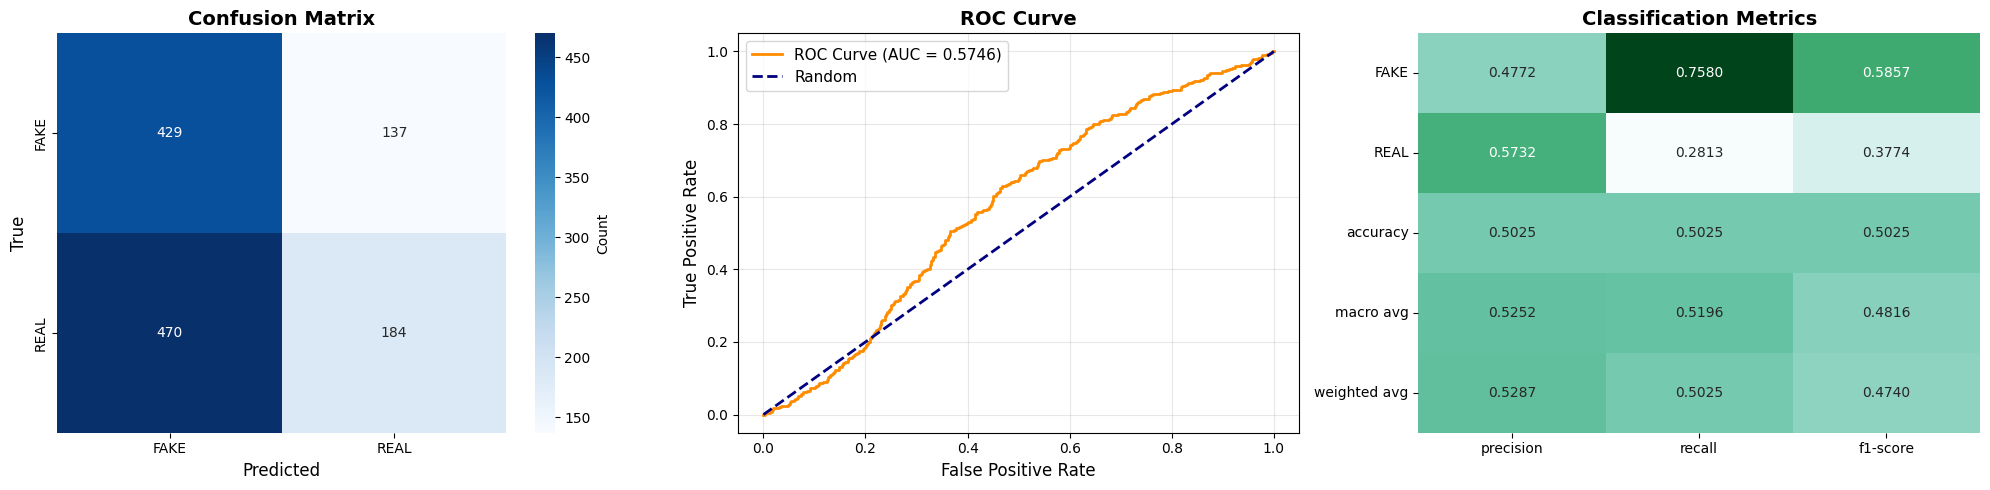


📋 CLASSIFICATION REPORT (Text):
              precision    recall  f1-score   support

        FAKE     0.4772    0.7580    0.5857       566
        REAL     0.5732    0.2813    0.3774       654

    accuracy                         0.5025      1220
   macro avg     0.5252    0.5196    0.4816      1220
weighted avg     0.5287    0.5025    0.4740      1220

✅ Visualizations complete!


In [25]:
# ============================================================================
# CNN-SRM Visualizations (Confusion Matrix + ROC + Metrics Table)
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Create figure with 3 subplots (Matrix, ROC, and Table)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ========== 1. Confusion Matrix ==========
ax1 = axes[0]
y_pred_binary = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred_binary)

# שימוש ב-'Blues' למטריצה
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('True', fontsize=12)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# ========== 2. ROC Curve ==========
ax2 = axes[1]
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', linewidth=2, linestyle='--', label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# ========== 3. Classification Report Table (Visual) ==========
ax3 = axes[2]

# יצירת הדוח כ-Dictionary
clf_report = classification_report(y_true, y_pred_binary,
                                 target_names=['FAKE', 'REAL'],
                                 output_dict=True)

# המרה ל-DataFrame והסרת שורת ה-Accuracy
report_df = pd.DataFrame(clf_report).iloc[:-1, :].T

# --- התיקון כאן: שינוי ל-'BuGn' (Blue-Green) במקום 'Teal' ---
sns.heatmap(report_df, annot=True, cmap='BuGn', fmt='.4f', ax=ax3, cbar=False)

ax3.set_title('Classification Metrics', fontsize=14, fontweight='bold')
ax3.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# הדפסה טקסטואלית לגיבוי
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT (Text):")
print("="*60)
print(classification_report(y_true, y_pred_binary, target_names=['FAKE', 'REAL'], digits=4))

print("✅ Visualizations complete!")

# Xception Model NO RUN !!

In [ ]:
# # ============================================================================
# # SECTION 5 - PART A: Input Layers & Preprocessing
# # ============================================================================
#
# # גודל התמונה הנדרש ע"י מודל Xception
# IMG_SIZE_XCEPTION = (299, 299)
# # גודל התמונה הגולמית שנטענת מהדיסק (כפי שהגדרת קודם)
# ORIGINAL_IMG_SIZE = (256, 256)
#
# # הגדרת הקלטים למודל - שני ערוצים (RGB ו-SRM)
# input_rgb = layers.Input(shape=(ORIGINAL_IMG_SIZE[0], ORIGINAL_IMG_SIZE[1], 3), name='rgb_input')
# input_srm = layers.Input(shape=(ORIGINAL_IMG_SIZE[0], ORIGINAL_IMG_SIZE[1], 3), name='srm_input') # עדיין 3 ערוצים כי SRM יופעל כשכבה
#
# # שכבת שינוי גודל ל-299x299 (סטנדרט של Xception)
# # זה קורה בתוך המודל, לפני ה-Xception
# resize_layer = layers.Resizing(IMG_SIZE_XCEPTION[0], IMG_SIZE_XCEPTION[1], name='resize_to_299')
#
# x_rgb = resize_layer(input_rgb)
# x_srm = resize_layer(input_srm) # גם ערוץ ה-SRM משנה גודל
#
# print("✅ Input layers and resizing defined.")

In [ ]:
# # ============================================================================
# # SECTION 5 - PART B.1: SRM Layer Definition
# # ============================================================================
#
# # הגדרת פילטרי SRM ידניים
# srm_filters = np.array([
#     [[[0, 0, -1, 0, 0], [0, -1, 2, -1, 0], [-1, 2, 4, 2, -1], [0, -1, 2, -1, 0], [0, 0, -1, 0, 0]]],
#     [[[-1, 2, -2, 2, -1], [2, -6, 8, -6, 2], [-2, 8, -12, 8, -2], [2, -6, 8, -6, 2], [-1, 2, -2, 2, -1]]],
#     [[[2, -1, 0, -1, 2], [-1, -2, 3, -2, -1], [0, 3, 0, 3, 0], [-1, -2, 3, -2, -1], [2, -1, 0, -1, 2]]],
#     [[[0, 0, 0, 0, 0], [1, -2, 1, -2, 1], [0, 0, 0, 0, 0], [-1, 2, -1, 2, -1], [0, 0, 0, 0, 0]]],
#     [[[1, -4, 6, -4, 1], [-4, 16, -24, 16, -4], [6, -24, 36, -24, 6], [-4, 16, -24, 16, -4], [1, -4, 6, -4, 1]]],
# ], dtype=np.float32)
#
# class SRMLayer(tf.keras.layers.Layer):
#     def __init__(self, **kwargs):
#         super(SRMLayer, self).__init__(**kwargs)
#         # שינוי פורמט הפילטרים ל-TensorFlow: (height, width, in_channels, out_channels)
#         srm_filters_transposed = np.transpose(srm_filters, (2, 3, 1, 0)) # (5, 5, 1, 5)
#         self.srm_kernels = tf.constant(srm_filters_transposed, dtype=tf.float32)
#
#     def call(self, inputs):
#         # פיצול ערוצי RGB
#         channels = tf.split(inputs, num_or_size_splits=3, axis=-1) # 3 x (batch, H, W, 1)
#         feature_maps = []
#         for channel in channels:
#             # הפעלת פילטרים על כל ערוץ
#             fm = tf.nn.conv2d(channel, self.srm_kernels, strides=1, padding='SAME')
#             feature_maps.append(fm)
#         # איחוד כל מפות המאפיינים חזרה: (batch, H, W, 15)
#         return tf.concat(feature_maps, axis=-1)
#
# srm_processor = SRMLayer(name='srm_processor_layer') # יצירת מופע של השכבה
# x_srm_processed = srm_processor(x_srm) # הפעלת שכבת ה-SRM על ערוץ ה-SRM
#
# print("✅ SRM filters and SRMLayer defined and applied to SRM stream.")

In [ ]:
# # ============================================================================
# # SECTION 5 - PART C: Classification Head & Final Model Assembly
# # ============================================================================
#
# # הוספת שכבות Dense (Fully Connected) מעל המיזוג
# x = layers.Dense(512, activation='relu', name='dense_head_1')(combined)
# x = layers.Dropout(0.5, name='dropout_head_1')(x) # למניעת Overfitting
# x = layers.Dense(256, activation='relu', name='dense_head_2')(x)
# x = layers.Dropout(0.3, name='dropout_head_2')(x)
#
# # שכבת פלט סופית: נוירון אחד עם Sigmoid לזיהוי בינארי (0 = Fake, 1 = Real)
# output = layers.Dense(1, activation='sigmoid', name='final_prediction')(x)
#
# # יצירת המודל המלא
# xception_dual_model = models.Model(inputs=[input_rgb, input_srm], outputs=output, name='deepfake_detector_xception_dual')
#
# # קומפילציה של המודל
# xception_dual_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # אופטימייזר Adam עם קצב למידה נמוך
#     loss='binary_crossentropy',                               # פונקציית הפסד לסיווג בינארי
#     metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]    # מדדי הערכה: דיוק ו-AUC
# )
#
# print("\n🎯 Final Xception Dual-Stream Model Compiled!")
# print("\n--- Model Summary ---")
# xception_dual_model.summary()
# print("\n--- End Model Summary ---")

In [ ]:
# # ============================================================================
# # עדכון נתיב מוחלט: הכנת הנתונים לאימון
# # ============================================================================
# import os
# import tensorflow as tf
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
#
# # הנתיב המוחלט שמצאנו ואימתנו
# DATASET_PATH = '/home/sceuser/RealEyes/gdrive/data_set_split'
# BATCH_SIZE = 8
#
# def prepare_dual_input(image, label):
#     return {'rgb_input': image, 'srm_input': image}, label
#
# print(f"🔄 טוען נתונים מהנתיב המוחלט: {DATASET_PATH}")
#
# try:
#     # טעינת הנתונים (הפעם בלי split ידני כי התיקיות train/val קיימות בנתיב)
#     train_ds_raw = tf.keras.utils.image_dataset_from_directory(
#         os.path.join(DATASET_PATH, 'train'),
#         label_mode='binary',
#         image_size=(224, 224),
#         batch_size=BATCH_SIZE,
#         shuffle=True
#     )
#
#     val_ds_raw = tf.keras.utils.image_dataset_from_directory(
#         os.path.join(DATASET_PATH, 'val'),
#         label_mode='binary',
#         image_size=(256, 256),
#         batch_size=BATCH_SIZE
#     )
#
#     train_ds = train_ds_raw.map(prepare_dual_input).prefetch(tf.data.AUTOTUNE)
#     val_ds = val_ds_raw.map(prepare_dual_input).prefetch(tf.data.AUTOTUNE)
#
#     print(f"✅ נמצאו {len(train_ds_raw.file_paths)} תמונות אימון.")
#     print(f"✅ נמצאו {len(val_ds_raw.file_paths)} תמונות ולידציה.")
#     print("🚀 המשתנים train_ds ו-val_ds מוכנים! אפשר לעבור לסקשן 6.")
#
# except Exception as e:
#     print(f"❌ שגיאה בטעינה: {e}")

In [ ]:
# # ============================================================================
# # בנייה מחדש של המודל ישירות על ה-GPU
# # ============================================================================
# import tensorflow as tf
#
# # ניקוי הזיכרון הקודם
# tf.keras.backend.clear_session()
#
# print("🛠️ Rebuilding model directly on GPU to fix Device alignment...")
#
# with tf.device('/device:GPU:0'):
#     # 1. הגדרת הקלטים
#     input_rgb = tf.keras.layers.Input(shape=(256, 256, 3), name='rgb_input')
#     input_srm = tf.keras.layers.Input(shape=(256, 256, 3), name='srm_input')
#
#     resize_layer = tf.keras.layers.Resizing(299, 299)
#     x_rgb = resize_layer(input_rgb)
#     x_srm = resize_layer(input_srm)
#
#     # 2. שכבת SRM ועיבוד
#     srm_processor = SRMLayer(name='srm_processor_layer') # ודאי שהגדרת את המחלקה קודם
#     x_srm_processed = srm_processor(x_srm)
#
#     # 3. טעינת ה-Backbones ישירות ל-GPU
#     base_xception_rgb = tf.keras.applications.Xception(
#         weights='imagenet', include_top=False, input_shape=(299, 299, 3), name='xception_rgb_gpu'
#     )
#     base_xception_srm = tf.keras.applications.Xception(
#         weights=None, include_top=False, input_shape=(299, 299, 15), name='xception_srm_gpu'
#     )
#
#     # 4. חיבור הזרמים
#     features_rgb = tf.keras.layers.GlobalAveragePooling2D()(base_xception_rgb(x_rgb))
#     features_srm = tf.keras.layers.GlobalAveragePooling2D()(base_xception_srm(x_srm_processed))
#     combined = tf.keras.layers.Concatenate()([features_rgb, features_srm])
#
#     # 5. ראש הסיווג
#     x = tf.keras.layers.Dense(512, activation='relu')(combined)
#     x = tf.keras.layers.Dropout(0.5)(x)
#     output = tf.keras.layers.Dense(1, activation='sigmoid')(x)
#
#     # יצירה וקומפילציה
#     xception_dual_model = tf.keras.models.Model(inputs=[input_rgb, input_srm], outputs=output)
#
#     xception_dual_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
#         loss='binary_crossentropy',
#         metrics=['accuracy']
#     )
#
# print("✅ Model rebuilt successfully on GPU. Ready for training!")

In [ ]:
# # ============================================================================
# # SECTION 6: TRAINING THE XCEPTION DUAL-STREAM MODEL
# # ============================================================================
# import os
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
#
# # 1. הגדרת תיקייה לשמירה
# save_dir = 'models/xception_dual'
# os.makedirs(save_dir, exist_ok=True)
# checkpoint_path = os.path.join(save_dir, 'best_xception_model.keras')
#
# # 2. הגדרת Callbacks (הגנות האימון)
# callbacks = [
#     # שומר רק את הגרסה הכי טובה של המודל
#     ModelCheckpoint(filepath=checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
#     # עוצר את האימון אם אין שיפור כדי לא לבזבז זמן GPU
#     EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
#     # מוריד את קצב הלמידה אם המודל נתקע (עוזר לדייק בסוף)
#     ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
# ]
#
# # 3. הגדרת פרמטרים
# EPOCHS = 20 # מספר הפעמים שנעבור על כל הדאטה
#
# print(f"🚀 Starting training... Monitoring GPU usage now!")
#
# # 4. הפעלת האימון
# # שימי לב: המודל יקבל את train_ds שבנינו (המכיל גם RGB וגם SRM)
# history = xception_dual_model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     callbacks=callbacks,
#     verbose=1
# )
#
# print("\n✅ Training Complete!")

# EfficientNetB0 Model NEW

In [ ]:
# ============================================================================
# SECTION 5.1: Prepare Data for EfficientNet (224x224, Batch 8)
# ============================================================================
IMG_SIZE = (224, 224) # רזולוציה חסכונית יותר
BATCH_SIZE = 8        # Batch size קטן למניעת קריסת השרת

# פונקציה להכנת הקלט הכפול (RGB ו-SRM)
def prepare_dual_input(image, label):
    return {'rgb_input': image, 'srm_input': image}, label

# טעינת הנתונים מהנתיב המוחלט שמצאנו קודם
DATASET_PATH = '/home/sceuser/RealEyes/gdrive/data_set_split'

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
).map(prepare_dual_input).prefetch(tf.data.AUTOTUNE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, 'val'),
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
).map(prepare_dual_input).prefetch(tf.data.AUTOTUNE)

print(f"✅ Data prepared for EfficientNet with size {IMG_SIZE}")